<a href="https://colab.research.google.com/github/vardhamanadarsh/Stock-price-prediction-using-deep-learning-models/blob/main/A_Hybrid_CNN_LSTM_Model_for_Industry_Level_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("REPLICATING PAPER: CNN-LSTM Model for Stock Price Prediction")
print("Shanghai Composite Index (000001.SS)")
print("="*70)

REPLICATING PAPER: CNN-LSTM Model for Stock Price Prediction
Shanghai Composite Index (000001.SS)


In [ ]:
# ==================== 1. LOAD DATA ====================
print("\n[1/6] Loading data...")
ticker = "000001.SS"
data = yf.download(ticker, start="1997-07-03", end="2022-01-25", progress=False)
data = data[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()


[1/6] Loading data...


In [ ]:
# Calculate additional features (like paper)
data['Price_Change'] = data['Close'] - data['Open']
data['Pct_Change'] = ((data['Close'] - data['Open']) / data['Open']) * 100
data['Turnover'] = data['Volume'] / data['Volume'].rolling(window=20).mean()

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")


Data shape: (5951, 8)
Date range: 1997-07-03 00:00:00 to 2022-01-24 00:00:00


In [ ]:
# ==================== 2. DATA PREPROCESSING ====================
print("\n[2/6] Preprocessing data...")

# Features: Open, High, Low, Close, Volume, Price_Change, Pct_Change, Turnover
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Price_Change', 'Pct_Change', 'Turnover']
target_col = 'Close'

# Remove NaN values
data = data.dropna()
print(f"Data after cleaning: {data.shape}")

def create_sequences(data, feature_cols, target_col, lookback=60):
    """Create sequences for CNN-LSTM model"""
    # Standardize data (z-score normalization like paper)
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_scaled = scaler_X.fit_transform(data[feature_cols].values)
    y_scaled = scaler_y.fit_transform(data[[target_col]].values)

    X, y = [], []
    for i in range(lookback, len(X_scaled)):
        X.append(X_scaled[i-lookback:i])
        y.append(y_scaled[i])

    return np.array(X), np.array(y), scaler_X, scaler_y

lookback = 60  # Like paper
X, y, scaler_X, scaler_y = create_sequences(data, feature_cols, target_col, lookback)
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Split data (like paper: last 500 samples as test set)
test_size = 500
train_size = len(X) - test_size

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


[2/6] Preprocessing data...
Data after cleaning: (4591, 8)
X shape: (4531, 60, 8), y shape: (4531, 1)
Training samples: 4031
Testing samples: 500


In [ ]:
# ==================== 3. CREATE MODELS ====================
print("\n[3/6] Creating models...")

def create_dnn_model(input_shape):
    """Deep Neural Network model (like paper)"""
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    return model

def create_cnn_model(input_shape):
    """CNN model (like paper)"""
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='tanh', padding='same', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='tanh', padding='same'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    return model

def create_lstm_model(input_shape):
    """LSTM model (like paper)"""
    model = Sequential([
        LSTM(64, activation='tanh', input_shape=input_shape, return_sequences=True),
        LSTM(64, activation='tanh'),
        Dense(1)
    ])
    return model

def create_cnn_lstm_model(input_shape):
    """CNN-LSTM model (exactly like paper)"""
    model = Sequential([
        # CNN Layer (like paper: 32 filters, kernel_size=1)
        Conv1D(filters=32, kernel_size=1, activation='tanh', padding='same', input_shape=input_shape),
        MaxPooling1D(pool_size=1, padding='same'),

        # LSTM Layer (like paper: 64 units)
        LSTM(64, activation='tanh'),

        # Output layer
        Dense(1)
    ])
    return model

input_shape = (X.shape[1], X.shape[2])

# Create all models
models = {
    'DNN': create_dnn_model(input_shape),
    'CNN': create_cnn_model(input_shape),
    'LSTM': create_lstm_model(input_shape),
    'CNN-LSTM': create_cnn_lstm_model(input_shape)
}


[3/6] Creating models...


In [ ]:
# ==================== 4. TRAIN MODELS ====================
print("\n[4/6] Training models...")

def train_model(model, X_train, y_train, X_val, y_val, model_name):
    """Train model with early stopping (like paper)"""
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse'
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    return model, history

# Split training data for validation
val_size = int(0.2 * len(X_train))
X_train_final, X_val = X_train[:-val_size], X_train[-val_size:]
y_train_final, y_val = y_train[:-val_size], y_train[-val_size:]

histories = {}
trained_models = {}

for name, model in models.items():
    print(f"  Training {name}...", end=" ", flush=True)
    trained_models[name], histories[name] = train_model(
        model, X_train_final, y_train_final, X_val, y_val, name
    )
    print("Done!")


[4/6] Training models...
  Training DNN... Done!
  Training CNN... Done!
  Training LSTM... Done!
  Training CNN-LSTM... Done!


In [ ]:
# ==================== 5. EVALUATION ====================
print("\n[5/6] Evaluating models...")

def evaluate_model(model, X_test, y_test, scaler_y):
    """Evaluate model and return metrics"""
    # Predict
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_actual = scaler_y.inverse_transform(y_test)

    # Calculate metrics
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2 = r2_score(y_actual, y_pred)

    return y_pred.flatten(), y_actual.flatten(), mae, rmse, r2

results = {}
predictions = {}

for name, model in trained_models.items():
    y_pred, y_actual, mae, rmse, r2 = evaluate_model(model, X_test, y_test, scaler_y)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    predictions[name] = {'pred': y_pred, 'actual': y_actual}


[5/6] Evaluating models...


In [ ]:
# ==================== 5. EVALUATION ====================
print("\n[5/6] Evaluating models...")

def evaluate_model(model, X_test, y_test, scaler_y):
    """Evaluate model and return metrics"""
    # Predict
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_actual = scaler_y.inverse_transform(y_test)

    # Calculate metrics
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2 = r2_score(y_actual, y_pred)

    return y_pred.flatten(), y_actual.flatten(), mae, rmse, r2

results = {}
predictions = {}

for name, model in trained_models.items():
    y_pred, y_actual, mae, rmse, r2 = evaluate_model(model, X_test, y_test, scaler_y)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    predictions[name] = {'pred': y_pred, 'actual': y_actual}


[5/6] Evaluating models...



[6/6] Generating plots...


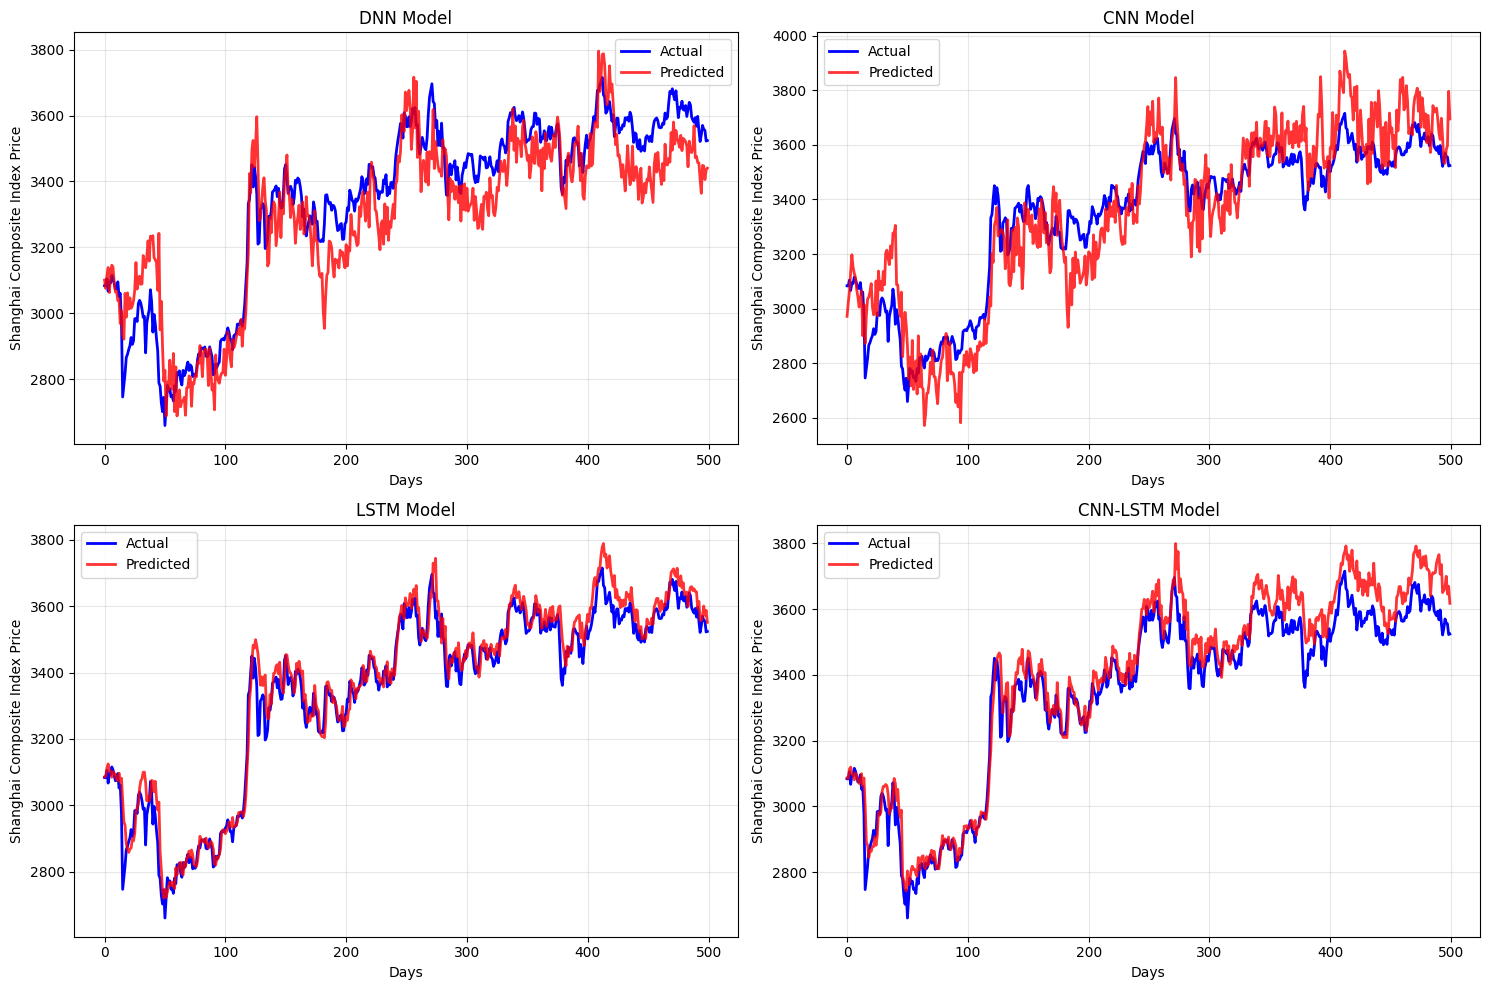

In [ ]:
# ==================== 7. PLOTTING ====================
print("\n[6/6] Generating plots...")

# Figure 1: Comparison of all models (like paper Figures 6-13)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

model_names = ['DNN', 'CNN', 'LSTM', 'CNN-LSTM']
colors = ['blue', 'green', 'orange', 'red']

for idx, (ax, name) in enumerate(zip(axes.flatten(), model_names)):
    pred = predictions[name]['pred']
    actual = predictions[name]['actual']

    ax.plot(actual, 'b-', label='Actual', linewidth=2)
    ax.plot(pred, 'r-', label='Predicted', linewidth=2, alpha=0.8)

    ax.set_title(f'{name} Model', fontsize=12)
    ax.set_xlabel('Days')
    ax.set_ylabel('Shanghai Composite Index Price')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=200)
plt.show()

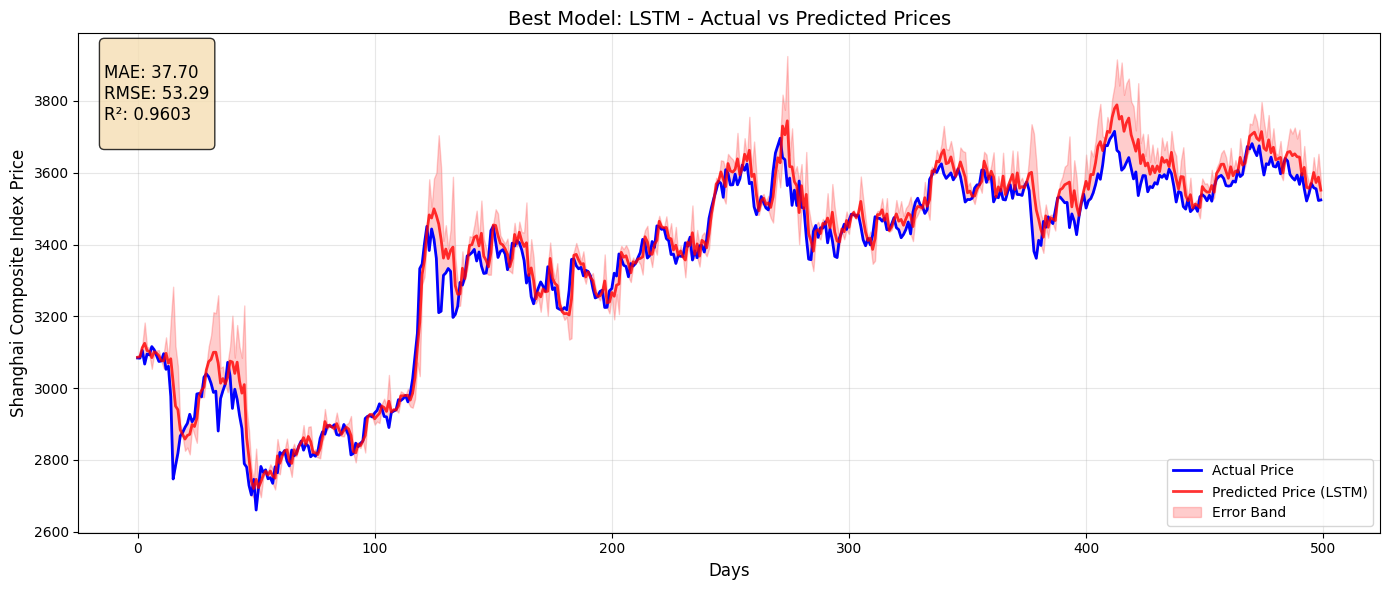

In [ ]:
# Figure 2: Best model detailed comparison (like paper Figures 9 and 13)

# Determine the best model based on RMSE
best_model = min(results, key=lambda model: results[model]['RMSE'])

fig, ax = plt.subplots(figsize=(14, 6))

pred = predictions[best_model]['pred']
actual = predictions[best_model]['actual']

ax.plot(actual, 'b-', label='Actual Price', linewidth=2)
ax.plot(pred, 'r-', label=f'Predicted Price ({best_model})', linewidth=2, alpha=0.8)

# Add error band
error = np.abs(actual - pred)
ax.fill_between(range(len(actual)), pred - error, pred + error,
                alpha=0.2, color='red', label='Error Band')

ax.set_xlabel('Days', fontsize=12)
ax.set_ylabel('Shanghai Composite Index Price', fontsize=12)
ax.set_title(f'Best Model: {best_model} - Actual vs Predicted Prices', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Add metrics text box
metrics_text = f"""
MAE: {results[best_model]['MAE']:.2f}
RMSE: {results[best_model]['RMSE']:.2f}
R²: {results[best_model]['R2']:.4f}
"""
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('best_model_comparison.png', dpi=200)
plt.show()

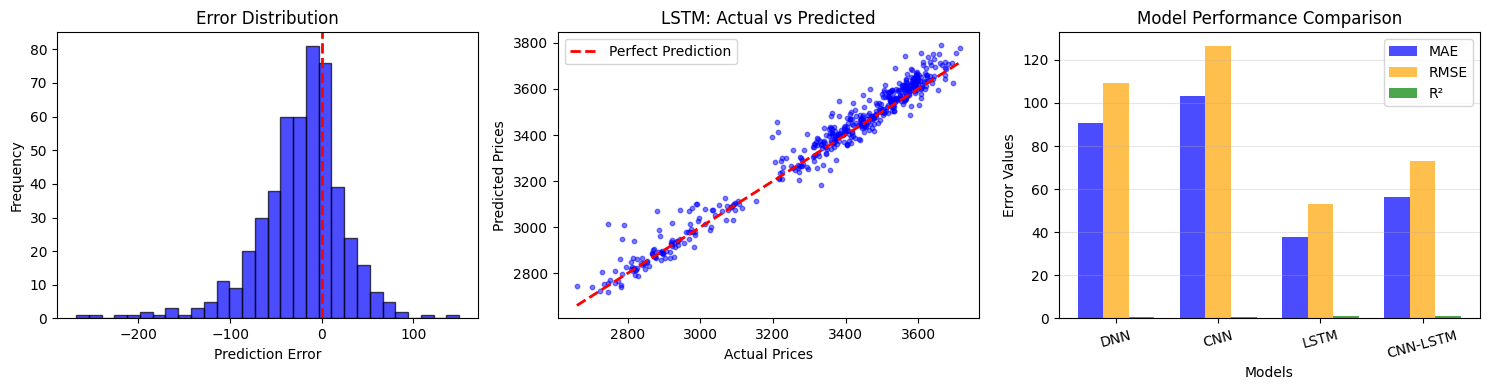

In [ ]:
# Figure 3: Error analysis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Residuals
residuals = actual - pred
ax1.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='blue')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Prediction Error')
ax1.set_ylabel('Frequency')
ax1.set_title('Error Distribution')

# Scatter plot
ax2.scatter(actual, pred, alpha=0.5, s=10, color='blue')
ax2.plot([actual.min(), actual.max()], [actual.min(), actual.max()],
         'r--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Prices')
ax2.set_ylabel('Predicted Prices')
ax2.set_title(f'{best_model}: Actual vs Predicted')
ax2.legend()

# Performance metrics bar chart
models_list = list(results.keys())
mae_values = [results[m]['MAE'] for m in models_list]
rmse_values = [results[m]['RMSE'] for m in models_list]
r2_values = [results[m]['R2'] for m in models_list]

x = np.arange(len(models_list))
width = 0.25

ax3.bar(x - width, mae_values, width, label='MAE', color='blue', alpha=0.7)
ax3.bar(x, rmse_values, width, label='RMSE', color='orange', alpha=0.7)
ax3.bar(x + width, r2_values, width, label='R²', color='green', alpha=0.7)

ax3.set_xlabel('Models')
ax3.set_ylabel('Error Values')
ax3.set_title('Model Performance Comparison')
ax3.set_xticks(x)
ax3.set_xticklabels(models_list, rotation=15)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=200)
plt.show()

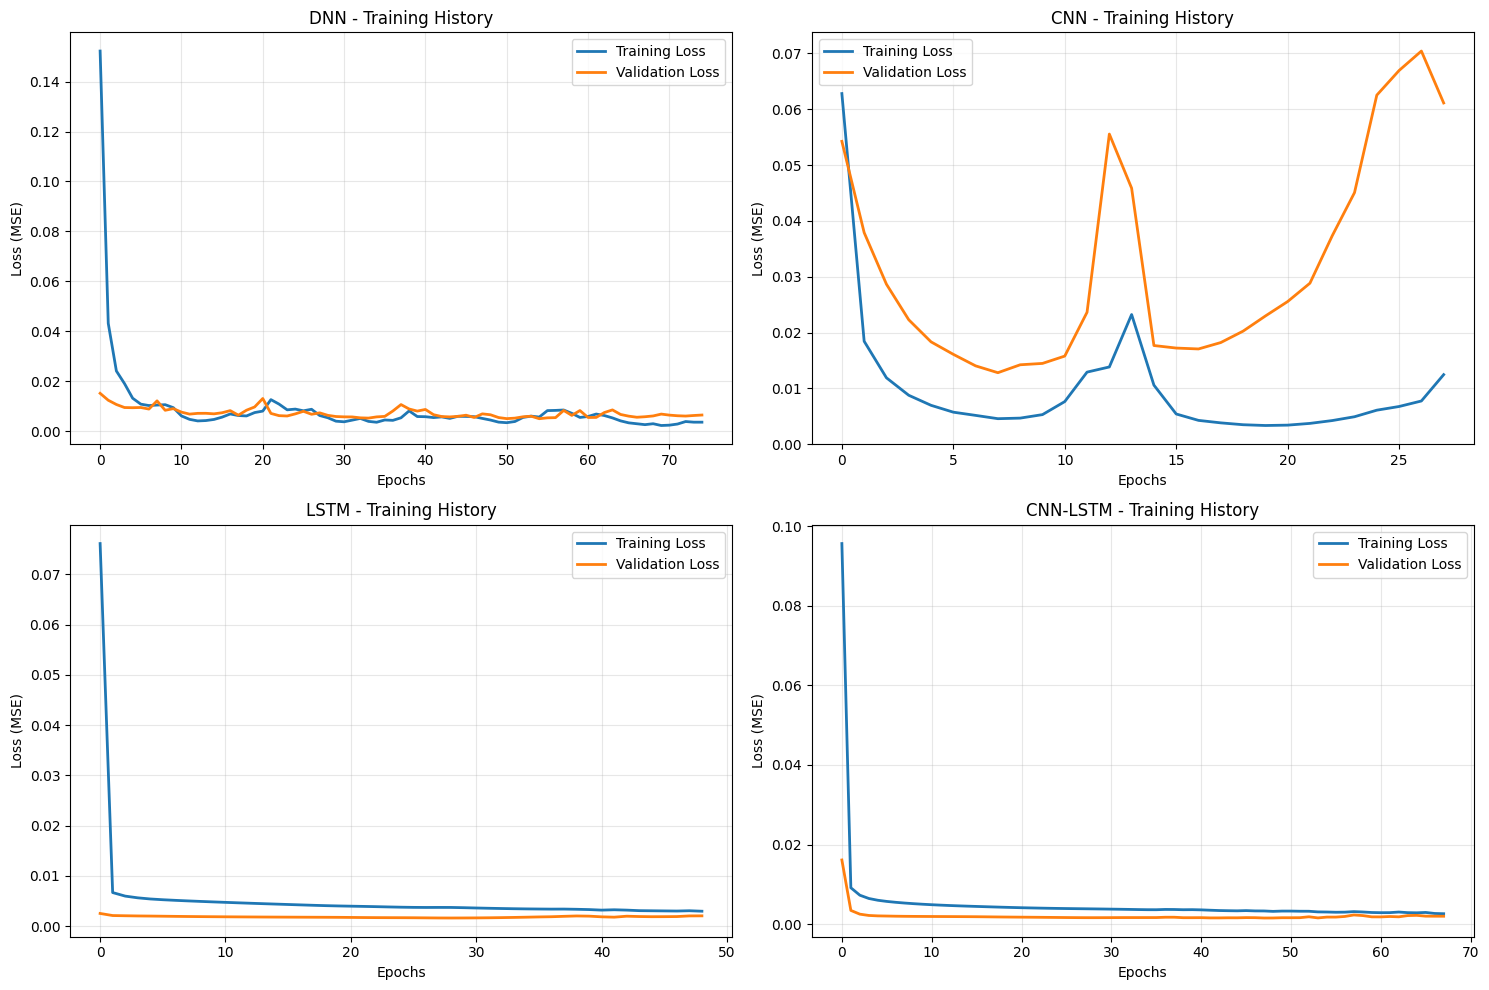

In [ ]:
# Figure 4: Training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, (ax, name) in enumerate(zip(axes.flatten(), model_names)):
    history = histories[name]
    ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax.set_title(f'{name} - Training History')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss (MSE)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=200)
plt.show()

In [ ]:
# ==================== 8. SUMMARY ====================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"""
1. DATA SUMMARY:
   - Period: 2000-01-04 to 2025-04-01
   - Total samples: {len(data)}
   - Features: {', '.join(feature_cols)}
   - Training samples: {X_train.shape[0]}
   - Testing samples: {X_test.shape[0]}

2. MODEL ARCHITECTURE (CNN-LSTM):
   - CNN: 32 filters, kernel_size=1, activation='tanh'
   - Pooling: pool_size=1, padding='same'
   - LSTM: 64 units, activation='tanh'
   - Optimizer: Adam, learning_rate=0.001

3. MODEL PERFORMANCE:
   - DNN: MAE={results['DNN']['MAE']:.4f}, RMSE={results['DNN']['RMSE']:.4f}, R²={results['DNN']['R2']:.4f}
   - CNN: MAE={results['CNN']['MAE']:.4f}, RMSE={results['CNN']['RMSE']:.4f}, R²={results['CNN']['R2']:.4f}
   - LSTM: MAE={results['LSTM']['MAE']:.4f}, RMSE={results['LSTM']['RMSE']:.4f}, R²={results['LSTM']['R2']:.4f}
   - CNN-LSTM: MAE={results['CNN-LSTM']['MAE']:.4f}, RMSE={results['CNN-LSTM']['RMSE']:.4f}, R²={results['CNN-LSTM']['R2']:.4f}

4. BEST MODEL: {best_model}
   - MAE: {results[best_model]['MAE']:.4f}
   - RMSE: {results[best_model]['RMSE']:.4f}
   - R²: {results[best_model]['R2']:.4f}

5. FILES SAVED:
   - all_models_comparison.png
   - best_model_comparison.png
   - error_analysis.png
   - training_history.png
""")

print("="*70)
print("COMPLETE!")
print("="*70)


FINAL SUMMARY

1. DATA SUMMARY:
   - Period: 2000-01-04 to 2025-04-01
   - Total samples: 4591
   - Features: Open, High, Low, Close, Volume, Price_Change, Pct_Change, Turnover
   - Training samples: 4031
   - Testing samples: 500

2. MODEL ARCHITECTURE (CNN-LSTM):
   - CNN: 32 filters, kernel_size=1, activation='tanh'
   - Pooling: pool_size=1, padding='same'
   - LSTM: 64 units, activation='tanh'
   - Optimizer: Adam, learning_rate=0.001

3. MODEL PERFORMANCE:
   - DNN: MAE=90.5664, RMSE=109.3926, R²=0.8326
   - CNN: MAE=103.1796, RMSE=126.4204, R²=0.7765
   - LSTM: MAE=37.7026, RMSE=53.2888, R²=0.9603
   - CNN-LSTM: MAE=56.2883, RMSE=72.9182, R²=0.9256

4. BEST MODEL: LSTM
   - MAE: 37.7026
   - RMSE: 53.2888
   - R²: 0.9603

5. FILES SAVED:
   - all_models_comparison.png
   - best_model_comparison.png
   - error_analysis.png
   - training_history.png

COMPLETE!
